# Fingernail Disease Classification  Data Preparation Module

This notebook prepares the **Fingernails** category dataset for a
multi-class nail disease classifier (8 classes: ALM, Blue_finger,
Clubbing, Healthy_Nail, Nail_Psoriasis, Onychogryphosis, Onychomycosis,
Pitting).

**Dataset:** [Nail Disease Dataset — Roboflow](https://universe.roboflow.com/nail-9c4um/nail-disease-op0e2-4jwa4/browse?queryText=&pageSize=50&startingIndex=0&browseQuery=true)

**Pipeline covered in this notebook:**
1. Load raw dataset (train/valid/test) into a unified dataframe
2. Detect a class-correlated black export-padding artifact
3. Auto-crop + resize to 224x224 (ViT-B/16 input size)
4. Detect residual rotation-wedge artifacts, fix via deskew + tight crop
5. Filter out images where the artifact could not be fully removed
6. Verify final dataset is artifact-free (0% across all 8 classes)

**Final output:** `final_clean` dataframe (5,108 images) with a
`final_path` column pointing to the cleaned, decontaminated images at
`/kaggle/working/nail_disease_final/<class_name>/<filename>`

In [2]:
#step 1 laoding dataset
import os
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/kaggle/input/datasets/muhammmadsarmad/nail-disease")
SPLITS = ["train", "valid", "test"]
CLASSES = sorted(os.listdir(DATA_ROOT / "train"))
print(f"Classes: {CLASSES}")

records = []
for split in SPLITS:
    for cls in CLASSES:
        for fname in sorted(os.listdir(DATA_ROOT / split / cls)):
            records.append({"path": str(DATA_ROOT / split / cls / fname),
                             "filename": fname, "split": split, "class_name": cls})
df = pd.DataFrame(records)
print(f"Total raw images: {len(df)}")

Classes: ['ALM', 'Blue_finger', 'Clubbing', 'Healthy_Nail', 'Nail_Psoriasis', 'Onychogryphosis', 'Onychomycosis', 'Pitting']
Total raw images: 5886


In [20]:
#Step_2:Detect black border artifact
def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

clean = df.copy()
clean["box_artifact"] = clean["path"].apply(has_box_artifact)

summary = clean.groupby("class_name")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary.sort_values("pct", ascending=False))

                 sum  count   pct
class_name                       
Pitting          425    655  64.9
Blue_finger      394    612  64.4
Onychogryphosis  495    789  62.7
ALM              529    859  61.6
Healthy_Nail     487    799  61.0
Clubbing         463    783  59.1
Nail_Psoriasis    44    608   7.2
Onychomycosis     29    781   3.7


In [21]:
#Step_3:Auto-crop + resiz
OUTPUT_DIR = Path("/kaggle/working/nail_disease_decontaminated")
IMG_SIZE = (224, 224)

def auto_crop_content(img, dark_thresh=15):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > dark_thresh
    if mask.sum() == 0:
        return img
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img[y0:y1, x0:x1]

new_paths = []
for _, row in clean.iterrows():
    cls_dir = OUTPUT_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)
    img = cv2.imread(row["path"])
    cropped = auto_crop_content(img)
    resized = cv2.resize(cropped, IMG_SIZE, interpolation=cv2.INTER_AREA)
    dest_path = cls_dir / row["filename"]
    cv2.imwrite(str(dest_path), resized)
    new_paths.append(str(dest_path))

clean["decontaminated_path"] = new_paths
print(f"Decontaminated {len(clean)} images -> {OUTPUT_DIR}")

Decontaminated 5886 images -> /kaggle/working/nail_disease_decontaminated


In [22]:
#Step_4:Deskew fix for rotation wedges
def deskew_and_crop(img, dark_thresh=15, close_kernel=9):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (gray > dark_thresh).astype(np.uint8) * 255
    kernel = np.ones((close_kernel, close_kernel), np.uint8)
    mask_closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 0.1 * img.shape[0] * img.shape[1]:
        return img

    (rc_x, rc_y), (rc_w, rc_h), rc_angle = cv2.minAreaRect(largest)
    M = cv2.getRotationMatrix2D((rc_x, rc_y), rc_angle, 1.0)
    rotated = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]),
                              borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

    gray2 = cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)
    mask2 = gray2 > dark_thresh
    if mask2.sum() == 0:
        return rotated
    coords = np.argwhere(mask2)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return rotated[y0:y1, x0:x1]

FINAL_DIR = Path("/kaggle/working/nail_disease_final")
final_paths = []
for _, row in clean.iterrows():
    cls_dir = FINAL_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)
    img = cv2.imread(row["decontaminated_path"])
    fixed = deskew_and_crop(img)
    resized = cv2.resize(fixed, IMG_SIZE, interpolation=cv2.INTER_AREA)
    dest_path = cls_dir / row["filename"]
    cv2.imwrite(str(dest_path), resized)
    final_paths.append(str(dest_path))

clean["final_path"] = final_paths
clean["box_artifact_final"] = clean["final_path"].apply(has_box_artifact)
print(f"Deskewed {len(clean)} images -> {FINAL_DIR}")

Deskewed 5886 images -> /kaggle/working/nail_disease_final


In [23]:
#Step_5:Drop residual-artifact images
final_clean = clean[~clean["box_artifact_final"]].reset_index(drop=True)

before_counts = clean.groupby("class_name").size()
after_counts = final_clean.groupby("class_name").size()
report = pd.DataFrame({"before": before_counts, "after": after_counts})
report["dropped"] = report["before"] - report["after"]
report["drop_pct"] = (report["dropped"] / report["before"] * 100).round(1)
print(report.sort_values("drop_pct", ascending=False))
print(f"\nTotal: {len(clean)} -> {len(final_clean)} images "
      f"({len(clean)-len(final_clean)} dropped, {(1 - len(final_clean)/len(clean))*100:.1f}%)")

                 before  after  dropped  drop_pct
class_name                                       
Pitting             655    517      138      21.1
ALM                 859    692      167      19.4
Onychogryphosis     789    643      146      18.5
Blue_finger         612    527       85      13.9
Healthy_Nail        799    690      109      13.6
Clubbing            783    677      106      13.5
Nail_Psoriasis      608    585       23       3.8
Onychomycosis       781    777        4       0.5

Total: 5886 -> 5108 images (778 dropped, 13.2%)


In [24]:
#step_6:Summary stats
verify = final_clean.groupby("class_name")["box_artifact_final"].agg(["sum", "count"])
verify["pct"] = (verify["sum"] / verify["count"] * 100).round(2)
print("Artifact check (should all be 0.0):")
print(verify, "\n")

split_summary = final_clean.groupby(["class_name", "split"]).size().unstack(fill_value=0)
split_summary["Total"] = split_summary.sum(axis=1)
print("Class x Split breakdown:")
print(split_summary.sort_values("Total", ascending=False), "\n")

print(f"Final dataset: {len(final_clean)} images across {final_clean['class_name'].nunique()} classes")
print(f"Imbalance ratio: {split_summary['Total'].max() / split_summary['Total'].min():.2f}x")
print(f"Path column to use going forward: 'final_path'")

Artifact check (should all be 0.0):
                 sum  count  pct
class_name                      
ALM                0    692  0.0
Blue_finger        0    527  0.0
Clubbing           0    677  0.0
Healthy_Nail       0    690  0.0
Nail_Psoriasis     0    585  0.0
Onychogryphosis    0    643  0.0
Onychomycosis      0    777  0.0
Pitting            0    517  0.0 

Class x Split breakdown:
split            test  train  valid  Total
class_name                                
Onychomycosis      40    605    132    777
ALM                39    559     94    692
Healthy_Nail       30    554    106    690
Clubbing           31    548     98    677
Onychogryphosis    35    521     87    643
Nail_Psoriasis     27    461     97    585
Blue_finger        29    424     74    527
Pitting            25    412     80    517 

Final dataset: 5108 images across 8 classes
Imbalance ratio: 1.50x
Path column to use going forward: 'final_path'


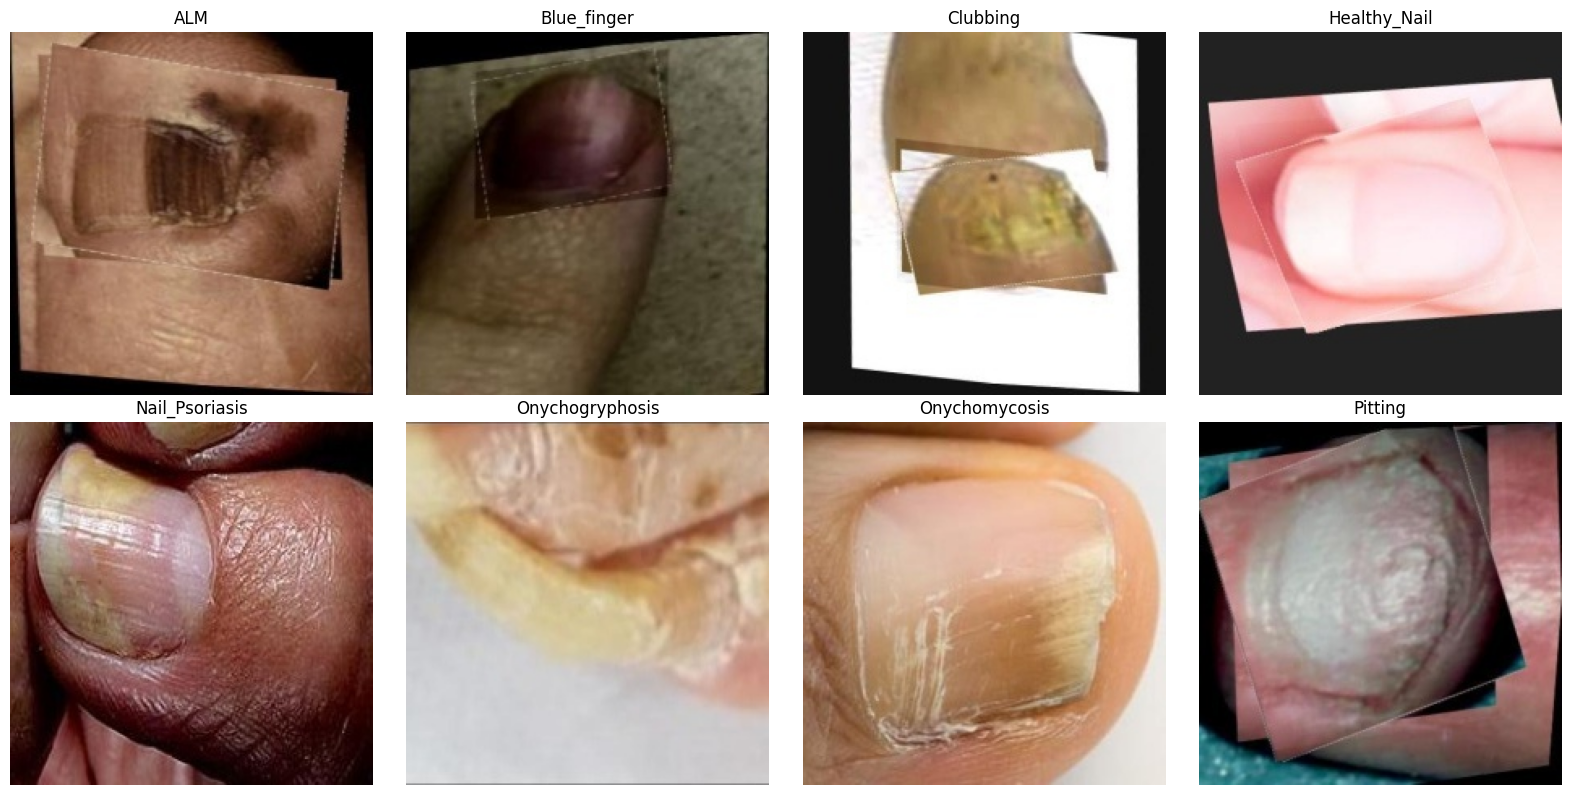

In [26]:
classes = sorted(final_clean["class_name"].unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, cls in zip(axes.flat, classes):
    row = final_clean[final_clean["class_name"] == cls].sample(1).iloc[0]
    img = cv2.imread(row["final_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()